# 02 — ARIMA Model

**Goal:** Forecast daily NO2 levels at MY1 (Marylebone Road) using ARIMA(p,d,q).

### Theory Recap
- **AR(p)** — Autoregressive: current value depends on **p** past values
- **I(d)** — Integrated: differencing **d** times to achieve stationarity
- **MA(q)** — Moving Average: current value depends on **q** past forecast errors

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q} + \varepsilon_t$$

In this notebook we will:
1. Load cleaned data from Notebook 01
2. Train/test split
3. Fit AR, MA, ARMA models first (building up to ARIMA)
4. Select best ARIMA(p,d,q) using AIC/BIC
5. Forecast and evaluate (RMSE, MAE)
6. Diagnose residuals (Ljung-Box, normality, heteroscedasticity)

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import norm, probplot, jarque_bera
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Cleaned Data

Shape: 1752 daily observations
Date range: 2019-01-01 → 2023-12-30


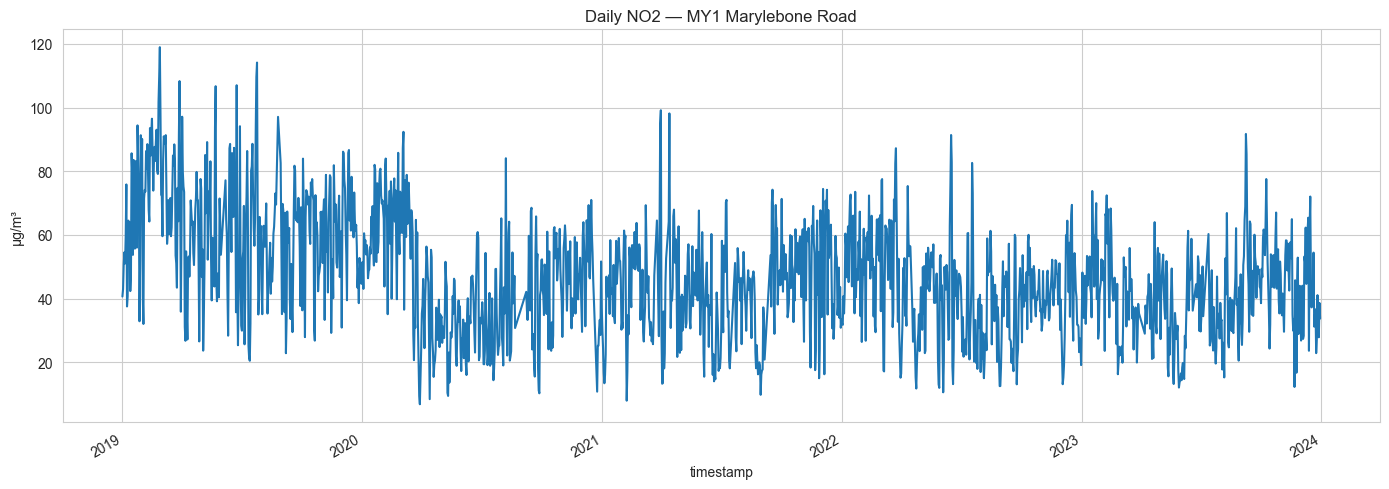

In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

# Focus on NO2 for ARIMA
no2 = df["no2"].copy()
print(f"Shape: {no2.shape[0]} daily observations")
print(f"Date range: {no2.index.min().date()} → {no2.index.max().date()}")
no2.plot(title="Daily NO2 — MY1 Marylebone Road", ylabel="µg/m³")
plt.tight_layout()
plt.show()

## 2. Train/Test Split

We hold out the **last 90 days** (~3 months) for testing. The model trains on everything before that.

Train: 1662 days  (2019-01-01 → 2023-10-01)
Test:  90 days  (2023-10-02 → 2023-12-30)


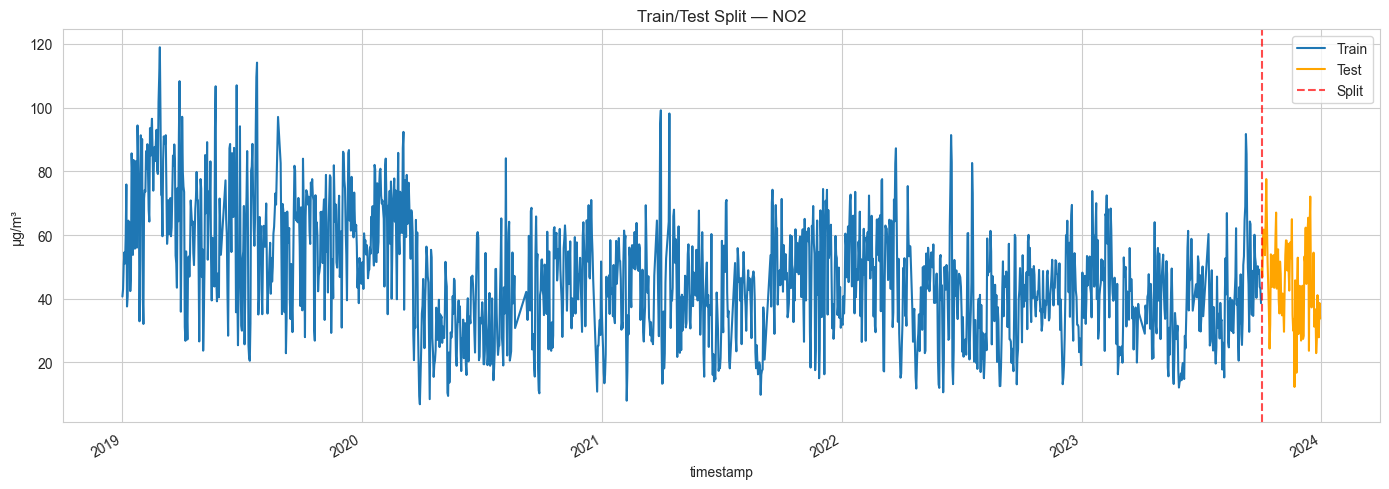

In [3]:
TEST_SIZE = 90  # days

train = no2[:-TEST_SIZE]
test = no2[-TEST_SIZE:]

print(f"Train: {len(train)} days  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:  {len(test)} days  ({test.index.min().date()} → {test.index.max().date()})")

fig, ax = plt.subplots(figsize=(14, 5))
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test", color="orange")
ax.axvline(test.index[0], color="red", linestyle="--", alpha=0.7, label="Split")
ax.set_title("Train/Test Split — NO2")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Building Up: AR → MA → ARMA → ARIMA

Before jumping to ARIMA, let's fit simpler models first to see how each component contributes.

### 3a. Pure AR Model

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

The PACF from Notebook 01 showed a cutoff at lag 2, so we try **AR(1)** and **AR(2)**.

AR(1)                | AIC: 13494.3 | BIC: 13510.6 | RMSE: 13.10 | MAE: 10.86
AR(2)                | AIC: 13496.3 | BIC: 13518.0 | RMSE: 13.10 | MAE: 10.86


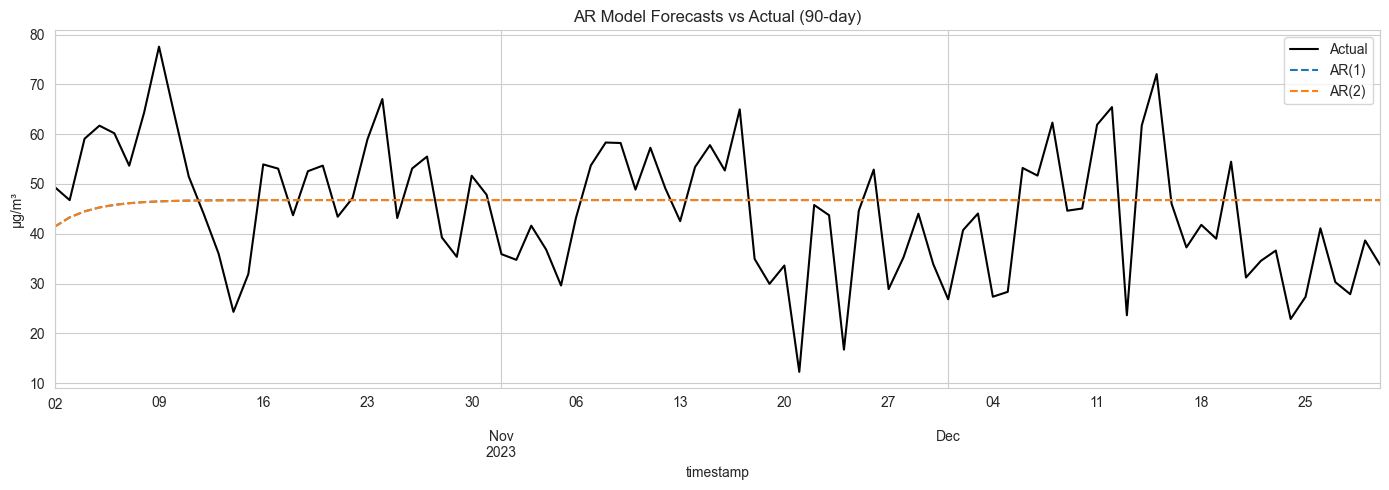

In [4]:
def evaluate_model(train, test, order, name=""):
    """Fit ARIMA, forecast, and return metrics."""
    model = ARIMA(train, order=order)
    fitted = model.fit()
    
    forecast = fitted.forecast(steps=len(test))
    
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    
    print(f"{name:20s} | AIC: {fitted.aic:.1f} | BIC: {fitted.bic:.1f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    return fitted, forecast, rmse, mae

# AR(1): ARIMA(1,0,0)
ar1_fit, ar1_fc, _, _ = evaluate_model(train, test, (1,0,0), "AR(1)")

# AR(2): ARIMA(2,0,0)
ar2_fit, ar2_fc, _, _ = evaluate_model(train, test, (2,0,0), "AR(2)")

# Plot AR forecasts
fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, ar1_fc, label="AR(1)", linestyle="--")
ax.plot(test.index, ar2_fc, label="AR(2)", linestyle="--")
ax.set_title("AR Model Forecasts vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Pure MA Model

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

The ACF from Notebook 01 (differenced) showed a cutoff at lag 1, so we try **MA(1)** and **MA(2)**.

MA(1)                | AIC: 13721.9 | BIC: 13738.2 | RMSE: 13.01 | MAE: 10.74
MA(2)                | AIC: 13600.4 | BIC: 13622.1 | RMSE: 13.01 | MAE: 10.76


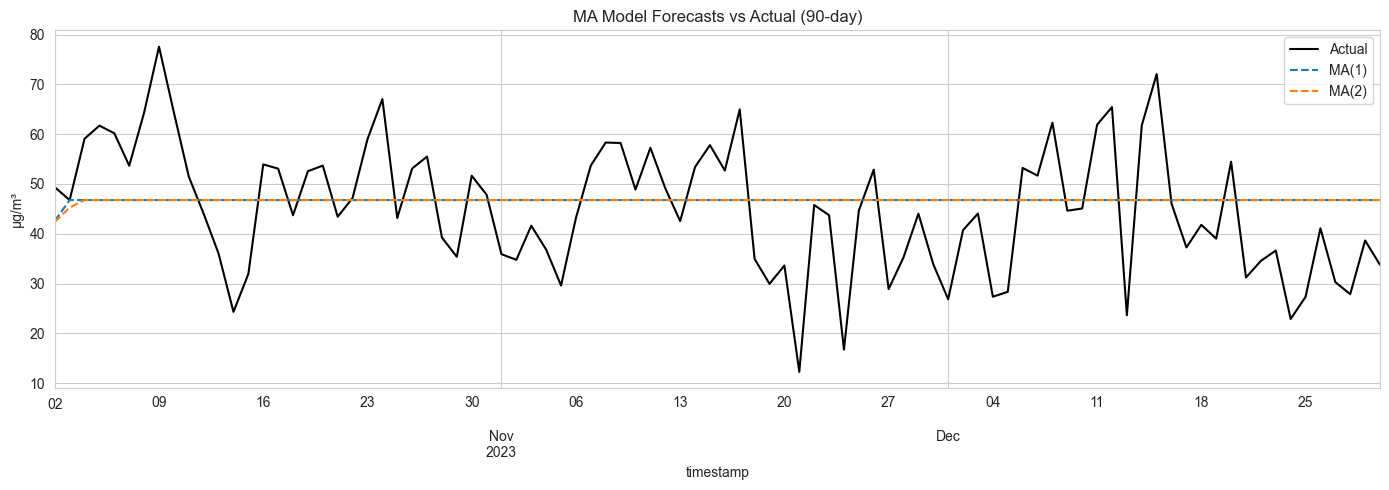

In [5]:
# MA(1): ARIMA(0,0,1)
ma1_fit, ma1_fc, _, _ = evaluate_model(train, test, (0,0,1), "MA(1)")

# MA(2): ARIMA(0,0,2)
ma2_fit, ma2_fc, _, _ = evaluate_model(train, test, (0,0,2), "MA(2)")

# Plot MA forecasts
fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, ma1_fc, label="MA(1)", linestyle="--")
ax.plot(test.index, ma2_fc, label="MA(2)", linestyle="--")
ax.set_title("MA Model Forecasts vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

### 3c. ARMA Model

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

Combining AR and MA — ARMA(1,1) and ARMA(2,1).

ARMA(1,1)            | AIC: 13496.3 | BIC: 13518.0 | RMSE: 13.10 | MAE: 10.86
ARMA(2,1)            | AIC: 13492.0 | BIC: 13519.1 | RMSE: 13.09 | MAE: 10.85


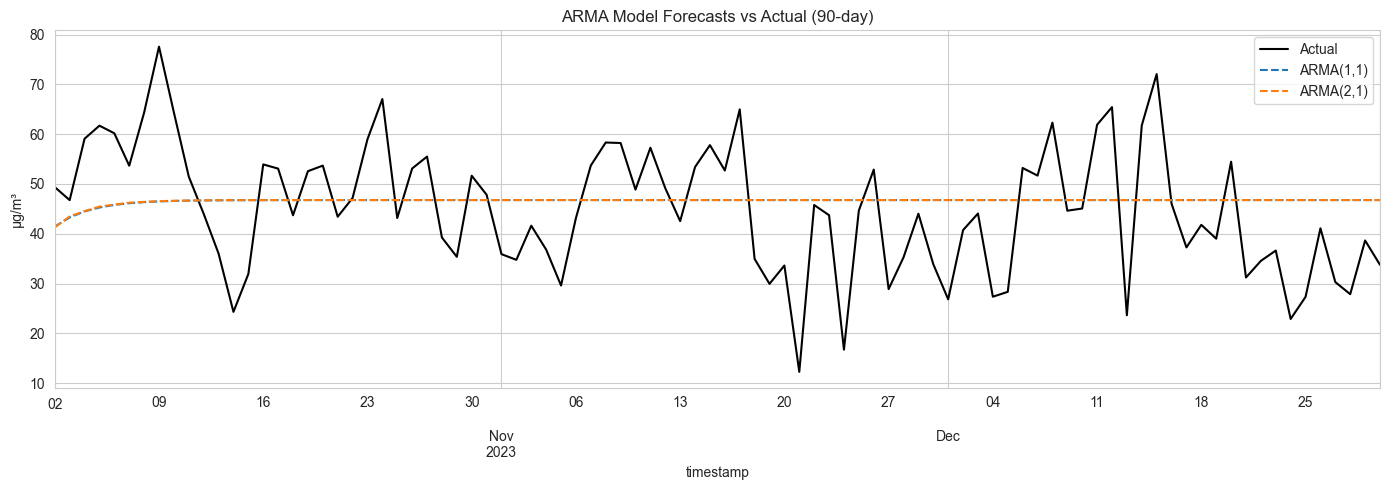

In [6]:
# ARMA(1,1): ARIMA(1,0,1)
arma11_fit, arma11_fc, _, _ = evaluate_model(train, test, (1,0,1), "ARMA(1,1)")

# ARMA(2,1): ARIMA(2,0,1)
arma21_fit, arma21_fc, _, _ = evaluate_model(train, test, (2,0,1), "ARMA(2,1)")

# Plot ARMA forecasts
fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, arma11_fc, label="ARMA(1,1)", linestyle="--")
ax.plot(test.index, arma21_fc, label="ARMA(2,1)", linestyle="--")
ax.set_title("ARMA Model Forecasts vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 4. ARIMA — Adding Differencing

Now we add **d=1** (first differencing) which made the series strongly stationary in Notebook 01.

$$\Delta y_t = c + \phi_1 \Delta y_{t-1} + \cdots + \theta_1 \varepsilon_{t-1} + \cdots + \varepsilon_t$$

ARIMA(1,1,0)         | AIC: 13749.9 | BIC: 13760.8 | RMSE: 14.10 | MAE: 11.56
ARIMA(0,1,1)         | AIC: 13644.8 | BIC: 13655.7 | RMSE: 13.00 | MAE: 10.60
ARIMA(1,1,1)         | AIC: 13368.2 | BIC: 13384.5 | RMSE: 12.91 | MAE: 10.60
ARIMA(2,1,1)         | AIC: 13346.6 | BIC: 13368.3 | RMSE: 12.93 | MAE: 10.66
ARIMA(2,1,2)         | AIC: 13347.5 | BIC: 13374.6 | RMSE: 12.92 | MAE: 10.64


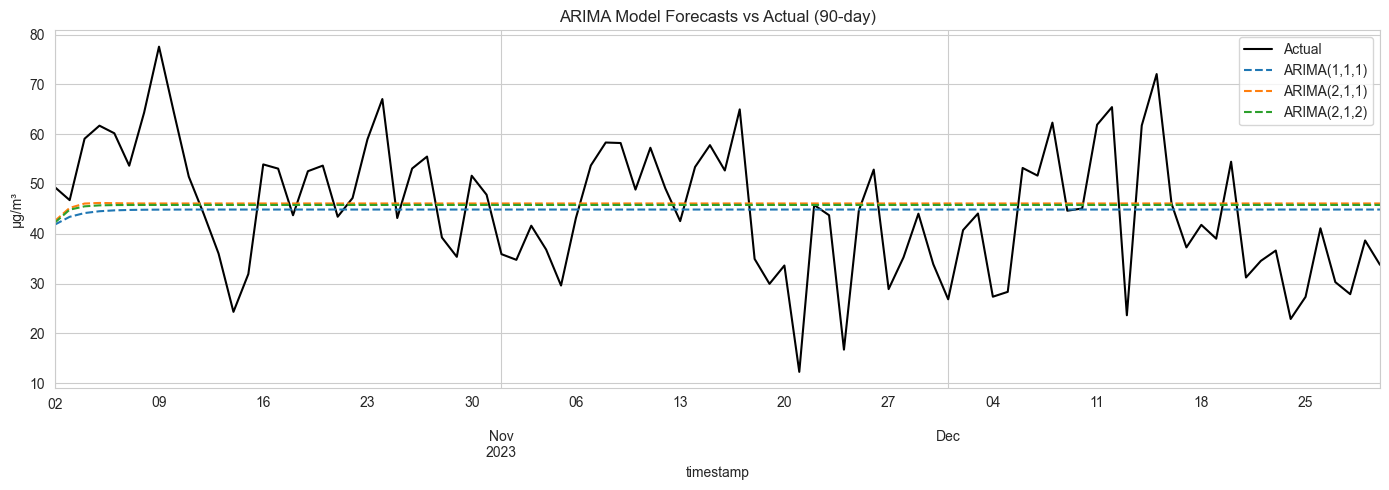

In [7]:
# ARIMA(1,1,0) — AR(1) with differencing
arima110_fit, arima110_fc, _, _ = evaluate_model(train, test, (1,1,0), "ARIMA(1,1,0)")

# ARIMA(0,1,1) — MA(1) with differencing
arima011_fit, arima011_fc, _, _ = evaluate_model(train, test, (0,1,1), "ARIMA(0,1,1)")

# ARIMA(1,1,1) — both AR and MA with differencing
arima111_fit, arima111_fc, _, _ = evaluate_model(train, test, (1,1,1), "ARIMA(1,1,1)")

# ARIMA(2,1,1)
arima211_fit, arima211_fc, _, _ = evaluate_model(train, test, (2,1,1), "ARIMA(2,1,1)")

# ARIMA(2,1,2)
arima212_fit, arima212_fc, _, _ = evaluate_model(train, test, (2,1,2), "ARIMA(2,1,2)")

# Plot ARIMA forecasts
fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, arima111_fc, label="ARIMA(1,1,1)", linestyle="--")
ax.plot(test.index, arima211_fc, label="ARIMA(2,1,1)", linestyle="--")
ax.plot(test.index, arima212_fc, label="ARIMA(2,1,2)", linestyle="--")
ax.set_title("ARIMA Model Forecasts vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Grid Search — Find Best ARIMA(p,d,q)

Systematically search over p ∈ {0,1,2,3}, d ∈ {0,1}, q ∈ {0,1,2,3} and rank by **AIC** (Akaike Information Criterion).

- **AIC** balances model fit vs complexity — lower is better
- **BIC** penalizes complexity more — also lower is better

In [8]:
results = []

for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                forecast = fitted.forecast(steps=len(test))
                rmse = np.sqrt(mean_squared_error(test, forecast))
                mae = mean_absolute_error(test, forecast)
                results.append({
                    "order": f"({p},{d},{q})",
                    "p": p, "d": d, "q": q,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                    "RMSE": rmse,
                    "MAE": mae,
                })
            except:
                continue

results_df = pd.DataFrame(results).sort_values("AIC")
print(f"Tested {len(results_df)} models\n")
print("Top 10 by AIC:")
display(results_df.head(10)[["order", "AIC", "BIC", "RMSE", "MAE"]].reset_index(drop=True))

Tested 32 models

Top 10 by AIC:


,order,AIC,BIC,RMSE,MAE
0,"(1,1,2)",13345.494161,13367.154861,12.922478,10.644041
1,"(2,1,1)",13346.626201,13368.286901,12.934670,10.662264
2,"(2,1,2)",13347.479853,13374.555728,12.921212,10.641701
3,"(1,1,3)",13347.488186,13374.564061,12.921875,10.642960
4,"(0,1,3)",13347.736011,13369.396711,12.943688,10.671829
5,"(3,1,1)",13348.031542,13375.107418,12.924683,10.647856
6,"(3,1,2)",13348.643323,13381.134374,12.926869,10.651176
7,"(2,1,3)",13349.436473,13381.927524,12.919994,10.639905
8,"(3,1,3)",13350.498782,13388.405008,12.930850,10.656901
9,"(2,0,2)",13351.975099,13384.469761,12.998545,10.736686


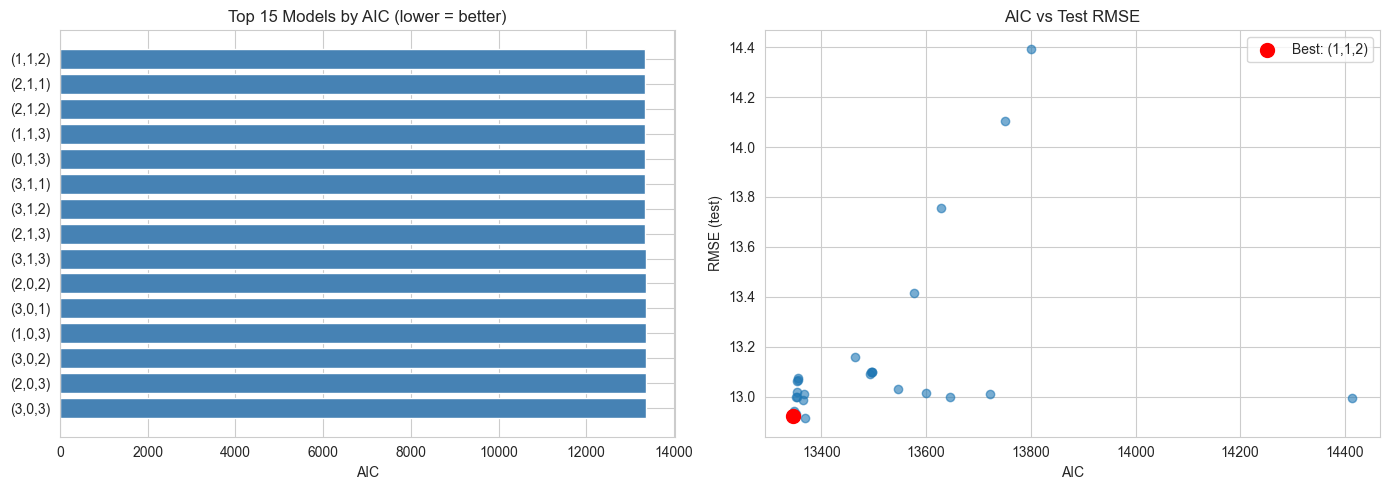

In [9]:
# Visualize AIC across models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AIC bar chart (top 15)
top15 = results_df.head(15)
axes[0].barh(top15["order"], top15["AIC"], color="steelblue")
axes[0].set_xlabel("AIC")
axes[0].set_title("Top 15 Models by AIC (lower = better)")
axes[0].invert_yaxis()

# RMSE vs AIC scatter
axes[1].scatter(results_df["AIC"], results_df["RMSE"], alpha=0.6)
axes[1].set_xlabel("AIC")
axes[1].set_ylabel("RMSE (test)")
axes[1].set_title("AIC vs Test RMSE")
best = results_df.iloc[0]
axes[1].scatter(best["AIC"], best["RMSE"], color="red", s=100, zorder=5, label=f"Best: {best['order']}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Best Model — Detailed Analysis

Fit the best ARIMA order and examine it in depth.

In [10]:
# Get best order from grid search
best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
print(f"Best ARIMA order: {best_order}\n")

# Fit best model
best_model = ARIMA(train, order=best_order)
best_fit = best_model.fit()
print(best_fit.summary())

Best ARIMA order: (1, 1, 2)

                               SARIMAX Results                                
Dep. Variable:                    no2   No. Observations:                 1662
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -6668.747
Date:                Fri, 03 Apr 2026   AIC                          13345.494
Time:                        23:40:57   BIC                          13367.155
Sample:                             0   HQIC                         13353.522
                               - 1662                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2644      0.046      5.755      0.000       0.174       0.354
ma.L1         -0.6874      0.046    -14.896      0.000      -0.778      -0.597
ma.L2         -0.2515  

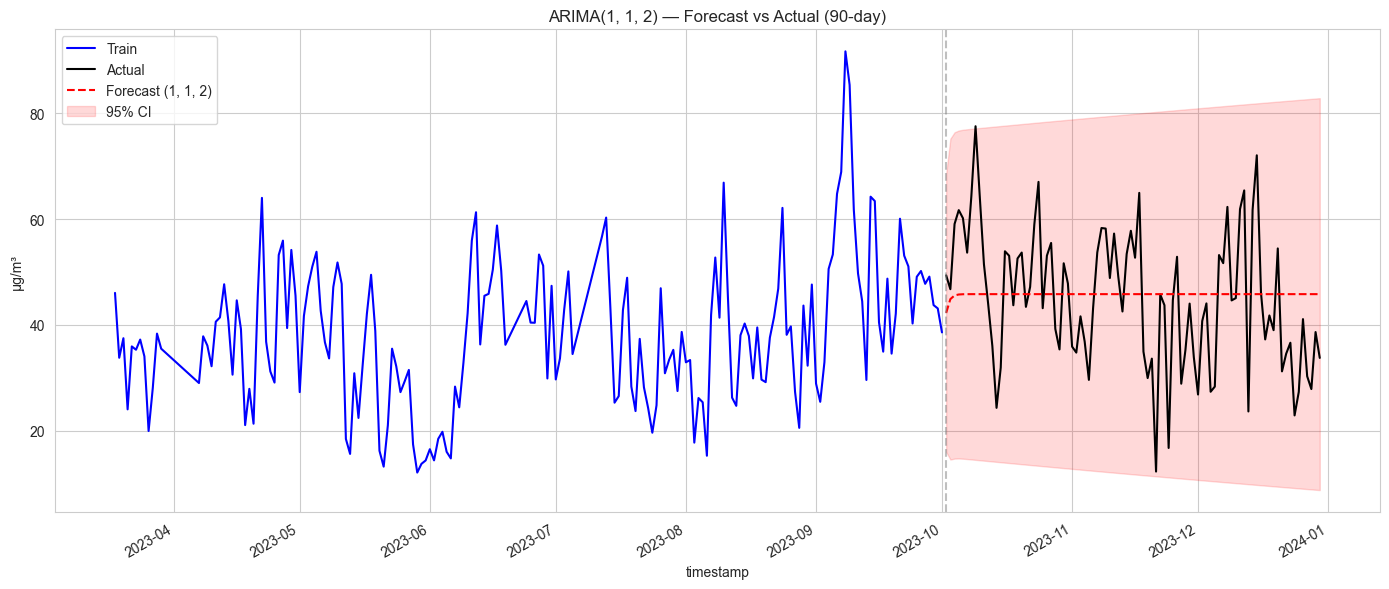

RMSE: 12.92 µg/m³
MAE:  10.64 µg/m³
MAPE: 23.6%


In [11]:
# Forecast with confidence intervals
forecast_result = best_fit.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot last 180 days of train + test
train[-180:].plot(ax=ax, label="Train", color="blue")
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, forecast_mean.values, label=f"Forecast {best_order}", color="red", linestyle="--")
ax.fill_between(test.index, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values,
                color="red", alpha=0.15, label="95% CI")

ax.axvline(test.index[0], color="gray", linestyle="--", alpha=0.5)
ax.set_title(f"ARIMA{best_order} — Forecast vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(test.values, forecast_mean.values))
mae = mean_absolute_error(test.values, forecast_mean.values)
mape = mae / test.mean() * 100
print(f"RMSE: {rmse:.2f} µg/m³")
print(f"MAE:  {mae:.2f} µg/m³")
print(f"MAPE: {mape:.1f}%")

## 7. Residual Diagnostics

A good model should have residuals that are:
1. **No autocorrelation** — Ljung-Box test (p > 0.05)
2. **Normally distributed** — histogram + Q-Q plot
3. **Constant variance** — no patterns in residual plot

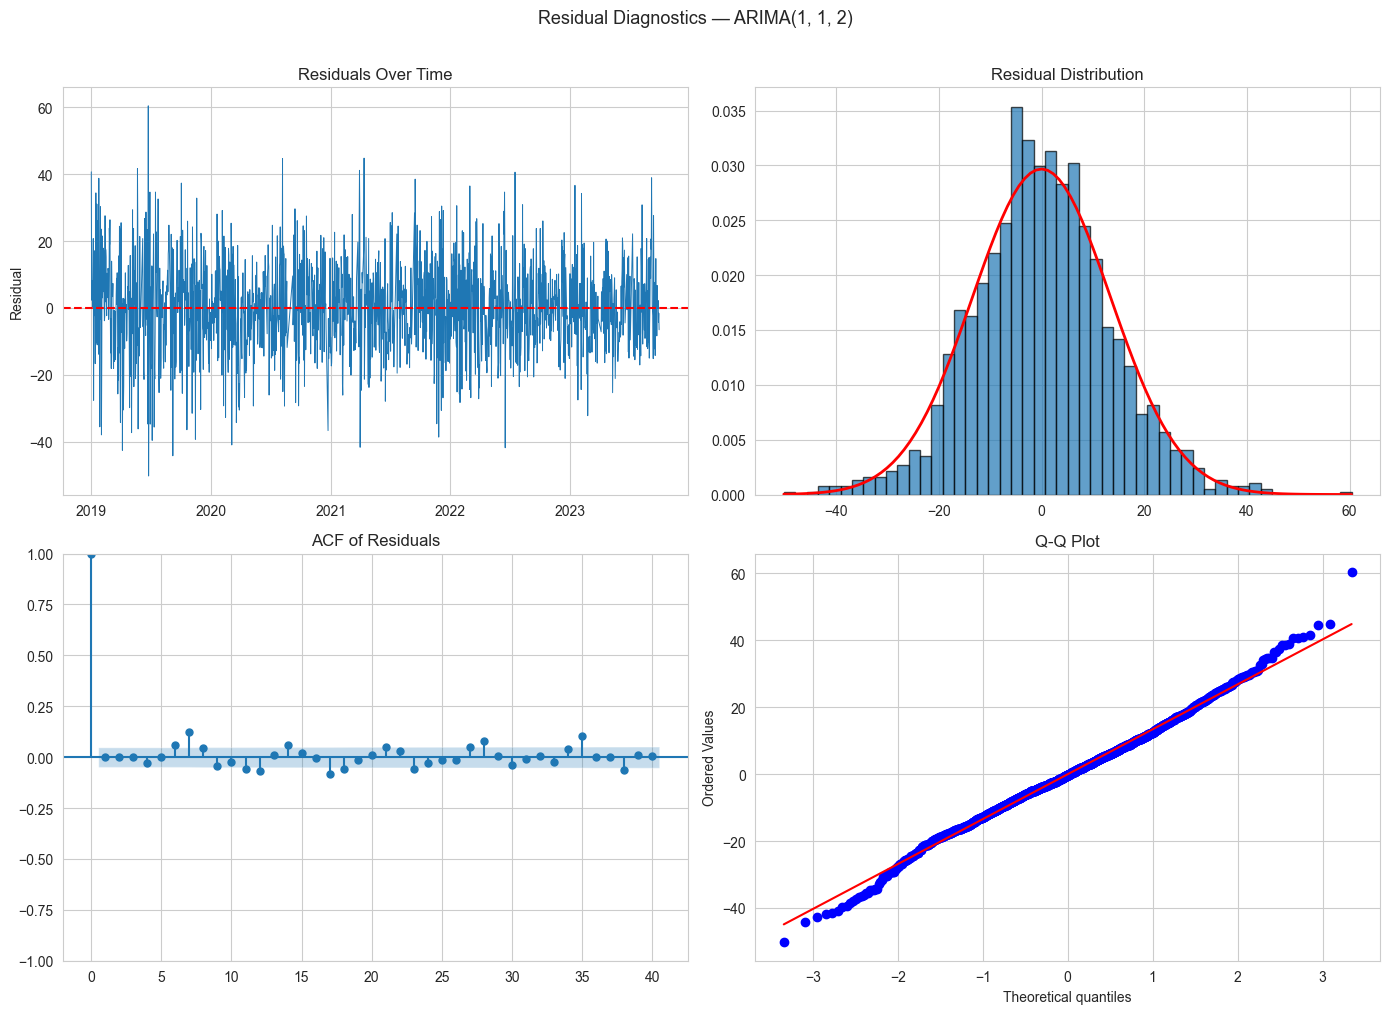

In [12]:
residuals = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(residuals, linewidth=0.7)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals Over Time")
axes[0, 0].set_ylabel("Residual")

# 2. Histogram + KDE
residuals.hist(bins=50, ax=axes[0, 1], density=True, edgecolor="black", alpha=0.7)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), "r-", linewidth=2)
axes[0, 1].set_title("Residual Distribution")

# 3. ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0], title="ACF of Residuals")

# 4. Q-Q plot
probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.suptitle(f"Residual Diagnostics — ARIMA{best_order}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Ljung-Box test on residuals
print("Ljung-Box Test on Residuals:\n")
lb_results = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
display(lb_results)

p_val = lb_results["lb_pvalue"].iloc[-1]
if p_val > 0.05:
    print(f"\n✓ p={p_val:.4f} > 0.05 — No significant autocorrelation in residuals (good!)")
else:
    print(f"\n✗ p={p_val:.4f} < 0.05 — Residuals still have autocorrelation (model can be improved)")

# Jarque-Bera normality test
jb_stat, jb_p = jarque_bera(residuals)
print(f"\nJarque-Bera Test: stat={jb_stat:.2f}, p={jb_p:.6f}")
if jb_p > 0.05:
    print("✓ Residuals are normally distributed")
else:
    print("✗ Residuals are NOT normally distributed (heavy tails likely)")

Ljung-Box Test on Residuals:



,lb_stat,lb_pvalue
10,41.374803,9.683965e-06
20,80.264237,3.540534e-09
30,111.661288,2.460276e-11



✗ p=0.0000 < 0.05 — Residuals still have autocorrelation (model can be improved)

Jarque-Bera Test: stat=33.01, p=0.000000
✗ Residuals are NOT normally distributed (heavy tails likely)


## 8. Walk-Forward Validation

A more realistic evaluation — retrain the model at each step and forecast **1 day ahead**, then slide forward. This simulates real-world usage.

  Step 30/90 done...
  Step 60/90 done...
  Step 90/90 done...

Walk-Forward Results (ARIMA(1, 1, 2)):
  RMSE: 11.61 µg/m³
  MAE:  9.31 µg/m³
  MAPE: 20.7%


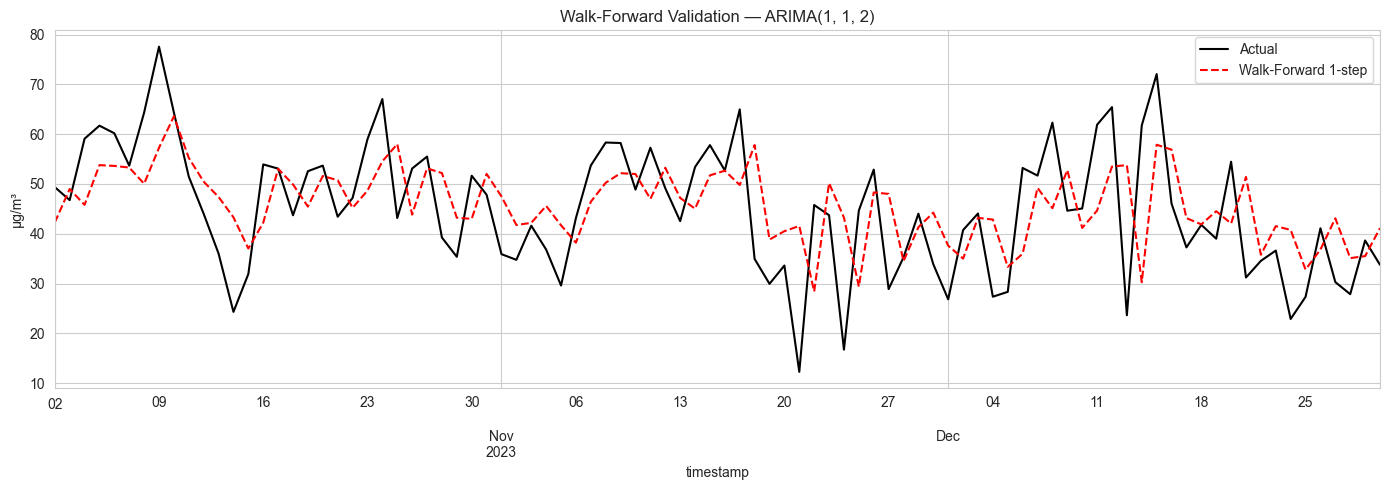

In [14]:
# Walk-forward: retrain every step, forecast 1 day at a time
history = list(train.values)
predictions = []

for i in range(len(test)):
    model = ARIMA(history, order=best_order)
    fitted = model.fit()
    pred = fitted.forecast(steps=1)[0]
    predictions.append(pred)
    history.append(test.values[i])  # add actual value to history
    
    if (i + 1) % 30 == 0:
        print(f"  Step {i+1}/{len(test)} done...")

wf_predictions = pd.Series(predictions, index=test.index)

# Metrics
wf_rmse = np.sqrt(mean_squared_error(test, wf_predictions))
wf_mae = mean_absolute_error(test, wf_predictions)
wf_mape = np.mean(np.abs(test - wf_predictions)) / test.mean() * 100

print(f"\nWalk-Forward Results (ARIMA{best_order}):")
print(f"  RMSE: {wf_rmse:.2f} µg/m³")
print(f"  MAE:  {wf_mae:.2f} µg/m³")
print(f"  MAPE: {wf_mape:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
wf_predictions.plot(ax=ax, label="Walk-Forward 1-step", color="red", linestyle="--")
ax.set_title(f"Walk-Forward Validation — ARIMA{best_order}")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Model Comparison Summary

,Method,RMSE,MAE,MAPE (%)
0,"ARIMA(1, 1, 2) (90-day static)",12.922478,10.644041,23.643277
1,"ARIMA(1, 1, 2) (walk-forward 1-step)",11.606069,9.310698,20.681564


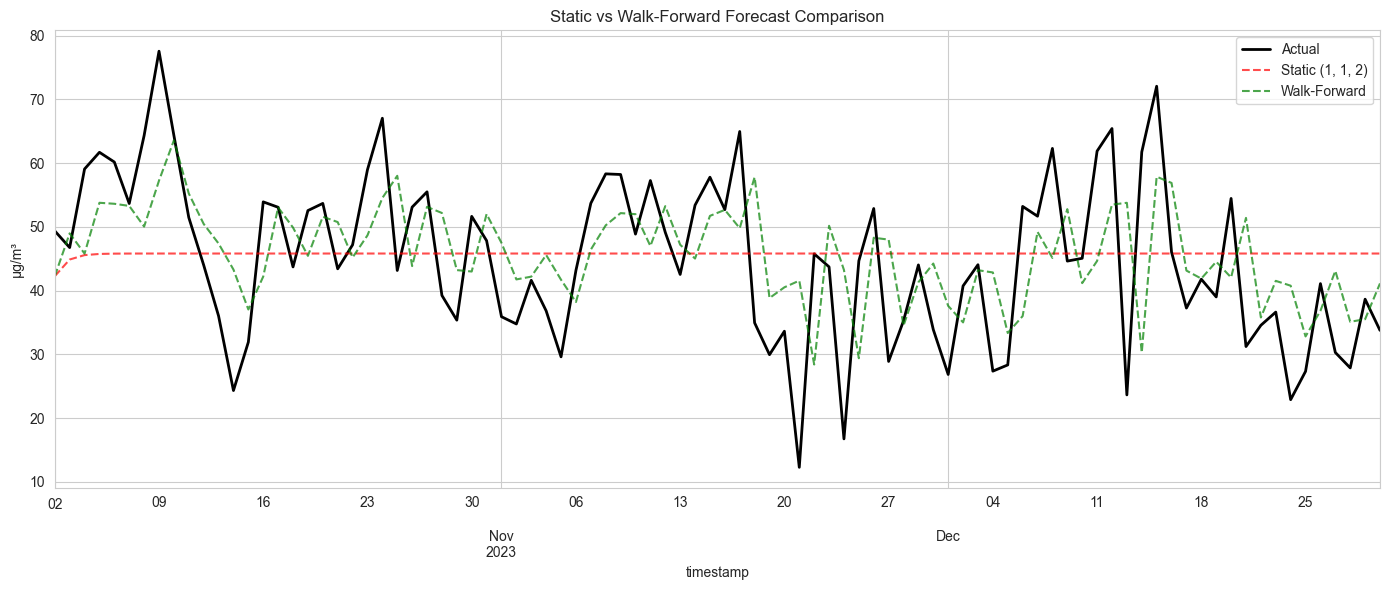


KEY TAKEAWAYS
• Best ARIMA order: (1, 1, 2)
• Walk-forward is much better than static (expected)
• ARIMA captures the mean level but misses weekly seasonality
• → Next: SARIMA (Notebook 03) will add seasonal component s=7


In [15]:
# Summary comparison: static forecast vs walk-forward
comparison = pd.DataFrame({
    "Method": [f"ARIMA{best_order} (90-day static)", f"ARIMA{best_order} (walk-forward 1-step)"],
    "RMSE": [rmse, wf_rmse],
    "MAE": [mae, wf_mae],
    "MAPE (%)": [mape, wf_mape],
})
display(comparison)

# Compare all model types visually
fig, ax = plt.subplots(figsize=(14, 6))
test.plot(ax=ax, label="Actual", color="black", linewidth=2)
ax.plot(test.index, forecast_mean, label=f"Static {best_order}", color="red", linestyle="--", alpha=0.7)
wf_predictions.plot(ax=ax, label="Walk-Forward", color="green", linestyle="--", alpha=0.7)
ax.set_title("Static vs Walk-Forward Forecast Comparison")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY TAKEAWAYS")
print("="*60)
print(f"• Best ARIMA order: {best_order}")
print(f"• Walk-forward is much better than static (expected)")
print(f"• ARIMA captures the mean level but misses weekly seasonality")
print(f"• → Next: SARIMA (Notebook 03) will add seasonal component s=7")